For Fig. 3B, Fig. S4C, D, F

Each column represents a plate in NRF2_signals.csv

Fluorescence was measured every minute for 30 minutes (cycle 1-31)

In the "Untransduced_T80K" plate, only wells C1–H5 are relevant (30 wells in total). Values in all other wells were set to NA because they are not relevant to the analysis.

In [1]:
suppressPackageStartupMessages({
library(tidyverse)
library(dplyr)
library(ggplot2)
library(ggrepel)
library(showtext)
library(sysfonts)
# Download Roboto from Google Font, which is same as in Biorender
font_add_google("Roboto", "roboto")

# Enable showtext rendering
showtext_auto()
showtext_opts(dpi = 96) 

# Optional: set a default theme with Roboto for all plots
theme_set(theme_grey(base_family = "roboto") +
          theme( text = element_text(color = "black"))
          )
})
set.seed(100)

In [2]:
# Load data
df <- read.csv("data/NRF2_signals.csv", check.names = TRUE, na.strings = c("NA", "#N/A"))
head(df)

,well_number,well_position,cycle_number,POOL_T80K_1,POOL_T80K_2,POOL_T80K_3,POOL_T80K_4,POOL_T80K_5,POOL_T80K_6,POOL_T80K_7,POOL_T80K_8,POOL_T80K_9,POOL_T80K_10,POOL_WT_1,Non.targeting,Untransduced_WT,Untransduced_T80K
,<int>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,A1,1,307631.5,328555.0,325680.7,319352.7,326676.2,310049.2,327271.9,295614.1,301199.6,270404.8,317286.1,314223.5,330155.0,NA
2,2,A2,1,279167.7,295817.4,297683.7,285960.2,308002.4,283898.4,292292.9,263410.4,280000.4,263674.1,283092.3,281361.7,296761.3,NA
3,3,A3,1,264356.9,295552.8,275675.8,279634.5,277984.1,273543.5,275188.7,260000.6,260342.0,257783.0,274230.5,272721.6,280746.2,NA
4,4,A4,1,250691.9,265606.3,263221.4,265096.0,266404.3,265058.8,268091.6,249378.2,250744.3,247594.2,263464.9,265196.0,266492.9,NA
5,5,A5,1,234261.2,247604.3,248414.8,241083.9,243833.0,251789.0,249384.4,239346.6,232672.1,237524.1,251423.3,246939.0,248338.2,NA
6,6,A6,1,197284.5,212623.3,209332.9,199465.0,205401.7,202403.0,210916.1,194545.0,200220.0,191567.8,216881.5,210296.8,209105.2,NA


In [3]:
#check the fluorescence at n minitute-time point
n <- 30

#fluorescence at cycle 1 (0 min)
df_0 <- df[df$cycle_number == 1, ] %>%
  select(-well_number, -well_position, -cycle_number)

#fluorescence at cycle n+1
df_n <- df[df$cycle_number == n+1, ] %>%
  select(-well_number, -well_position, -cycle_number)

#delta fluorescence (df_n minus df_0)
df_delta <- df_n-df_0
head(df_delta)

,POOL_T80K_1,POOL_T80K_2,POOL_T80K_3,POOL_T80K_4,POOL_T80K_5,POOL_T80K_6,POOL_T80K_7,POOL_T80K_8,POOL_T80K_9,POOL_T80K_10,POOL_WT_1,Non.targeting,Untransduced_WT,Untransduced_T80K
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2881,32832.94,5558.22,21552.16,5182.50,5076.44,991267.98,525681.36,33513.48,28145.24,15660.40,328531.8,1333424.7,685832.17,NA
2882,30295.72,27047.09,42050.05,40821.47,28190.20,21641.90,32076.72,32067.90,30935.57,23109.32,566894.8,840761.1,32642.14,NA
2883,41411.84,28654.98,29363.25,21859.19,23824.30,44778.69,38884.30,31272.48,34070.88,14623.58,1366737.6,1905542.2,274802.34,NA
2884,38214.36,29167.56,29381.18,28456.50,25273.66,26438.67,32171.84,43134.87,37198.84,41176.08,996158.1,1518706.1,1208300.52,NA
2885,40090.67,37058.20,25541.07,33185.10,36335.89,31783.57,37032.54,56144.80,37009.16,29287.02,591820.9,778236.4,764933.36,NA
2886,36083.19,34719.93,29161.26,34824.87,54834.28,44657.79,32197.05,43593.01,62986.26,70587.45,1724090.1,930199.0,37438.32,NA


# A tibble: 2 × 5
  Sample       PercentAbove n_total n_above PercentLabel
  <fct>               <dbl>   <int>   <int> <chr>       
1 untransduced         0         30       0 0%          
2 T80K                 4.79     960      46 4.8%        


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”
Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”


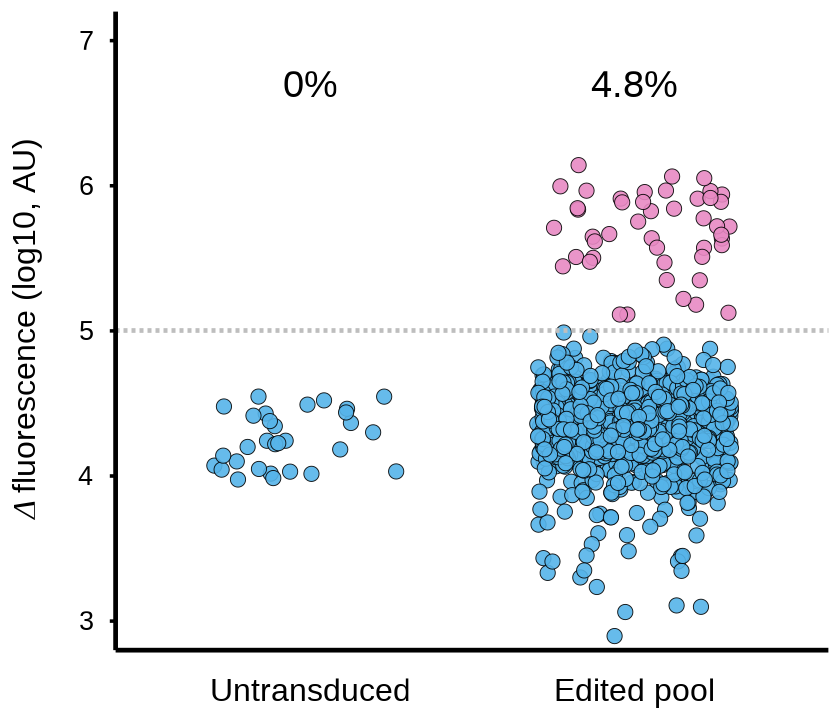

In [4]:
#result for T80K targeting
untransduced <- unlist(df_delta[ , "Untransduced_T80K"])
T80K <- unlist(df_delta[ , paste0("POOL_T80K_", 1:10)])

# Threshold on raw delta fluorescence
threshold_log10 <- 5
threshold_raw <- 10^threshold_log10

# Combine data
combined_df_all <- data.frame(
  Sample = rep(
    c("untransduced", "T80K"),
    c(length(untransduced), length(T80K))
  ),
  Value = c(untransduced, T80K)
) %>%
  filter(!is.na(Value)) %>%
  mutate(
    Sample = factor(Sample, levels = c("untransduced", "T80K")),
    AboveThreshold = Value > threshold_raw
  )

# Calculate percentage from all relevant wells, including negative/zero delta values
percent_df <- combined_df_all %>%
  group_by(Sample) %>%
  summarise(
    PercentAbove = mean(AboveThreshold) * 100,
    n_total = n(),
    n_above = sum(AboveThreshold),
    .groups = "drop"
  ) %>%
  mutate(
    PercentLabel = paste0(round(PercentAbove, 1), "%")
  )

print(percent_df)

# Plot only positive values because log10 cannot display zero/negative values
plot_df <- combined_df_all %>%
  filter(Value > 0) %>%
  mutate(Value_log10 = log10(Value))

# Plot
options(repr.plot.width = 7, repr.plot.height = 6)

p <- ggplot(plot_df, aes(x = Sample, y = Value_log10, fill = AboveThreshold)) +
  geom_jitter(
    color = "black",
    width = 0.3,
    alpha = 0.9,
    size = 3.8,
    shape = 21,
    stroke = 0.3
  ) +
  geom_hline(
    yintercept = threshold_log10,
    linetype = "dashed",
    color = "gray",
    size = 1
  ) +
  scale_fill_manual(
    values = c("FALSE" = "#56B4E9", "TRUE" = "#E78AC3"),
    labels = c("FALSE" = paste0("≤ 10^", threshold_log10),
               "TRUE" = paste0("> 10^", threshold_log10))
  ) +
  scale_x_discrete(
    labels = c(
      "untransduced" = "Untransduced",
      "T80K" = "Edited pool"
    )
  ) +
  coord_cartesian(ylim = c(3, 7)) +
  geom_text(
    data = percent_df,
    inherit.aes = FALSE,
    aes(
      x = Sample,
      y = 6.7,
      label = PercentLabel
    ),
    size = 10,
    color = "black"
  ) +
  theme_minimal(base_size = 14) +
  ylab(expression(Delta * " fluorescence (log10, AU)")) +
  theme(
    axis.text = element_text(size = 18),
    axis.text.x = element_text(size = 24, vjust = 0.5, hjust = 0.5,
                               margin = margin(t = 10), color = "black"),
    axis.text.y = element_text(size = 20, vjust = 0.5, hjust = 1,
                               margin = margin(r = 10), color = "black"),
    axis.title.x = element_blank(),
    axis.title.y = element_text(size = 24, margin = margin(r = 15), color = "black"),
    axis.ticks.x = element_blank(),
    axis.ticks.y = element_line(size = 0.75, color = "black"),
    legend.position = "none",
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    panel.border = element_blank(),
    axis.line = element_line(color = "black", size = 1)
  )
print(p)
ggsave("data/POOL_T80K_signal.pdf", plot = last_plot(), width = 8, height = 6, units = "in", device = cairo_pdf)

# A tibble: 3 × 5
  Sample       PercentAbove n_total n_above PercentLabel
  <fct>               <dbl>   <int>   <int> <chr>       
1 untransduced         93.8      96      90 93.8%       
2 negative             90.6      96      87 90.6%       
3 WT                   85.4      96      82 85.4%       


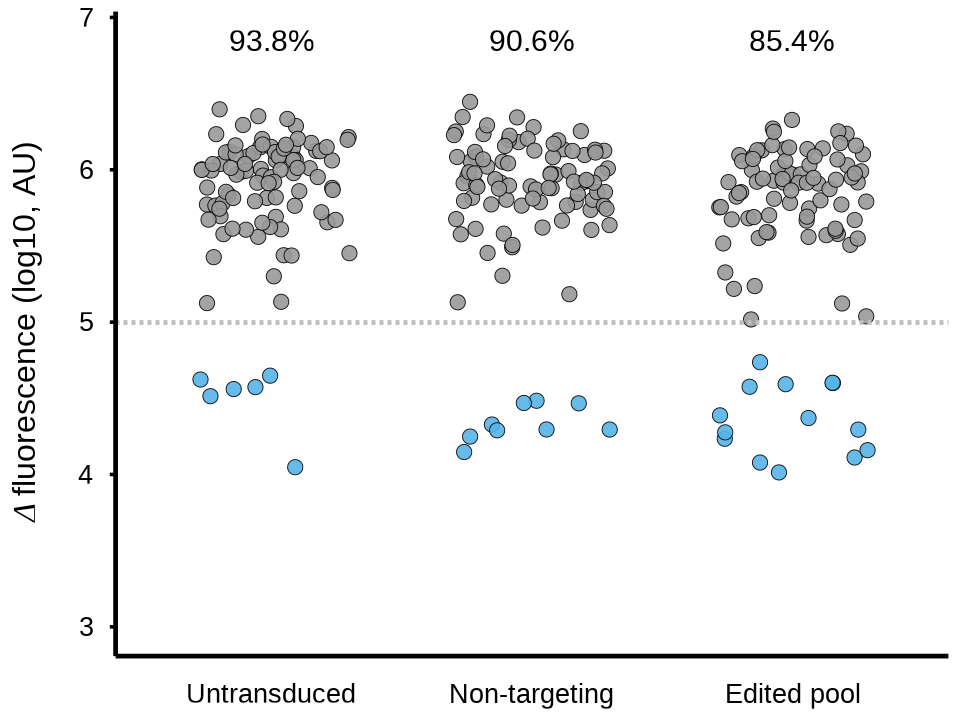

In [5]:
#result for WT targeting
untransduced <- unlist(df_delta[ , "Untransduced_WT"])
WT <- unlist(df_delta[ , "POOL_WT_1"])
negative <- unlist(df_delta[ , "Non.targeting"]) 

# Threshold on raw delta fluorescence
threshold_log10 <- 5
threshold_raw <- 10^threshold_log10

# Combine data
combined_df_all <- data.frame(
  Sample = rep(
    c("untransduced", "WT", "negative"),
    c(length(untransduced), length(WT), length(negative))
  ),
  Value = c(untransduced, WT, negative)
) %>%
  filter(!is.na(Value)) %>%
  mutate(
    Sample = factor(Sample, levels = c("untransduced", "negative", "WT")),
    AboveThreshold = Value > threshold_raw
  )

# Calculate percentage from all relevant wells, including negative/zero delta values
percent_df <- combined_df_all %>%
  group_by(Sample) %>%
  summarise(
    PercentAbove = mean(AboveThreshold) * 100,
    n_total = n(),
    n_above = sum(AboveThreshold),
    .groups = "drop"
  ) %>%
  mutate(
    PercentLabel = paste0(round(PercentAbove, 1), "%")
  )

print(percent_df)

# Plot only positive values because log10 cannot display zero/negative values
plot_df <- combined_df_all %>%
  filter(Value > 0) %>%
  mutate(Value_log10 = log10(Value))

# Plot
options(repr.plot.width = 8, repr.plot.height = 6)

p <- ggplot(plot_df, aes(x = Sample, y = Value_log10, fill = AboveThreshold)) +
  geom_jitter(
    color = "black",
    width = 0.3,
    alpha = 0.9,
    size = 3.8,
    shape = 21,
    stroke = 0.3
  ) +
  geom_hline(
    yintercept = threshold_log10,
    linetype = "dashed",
    color = "gray",
    size = 1
  ) +
  scale_fill_manual(
    values = c("FALSE" = "#56B4E9", "TRUE" = "#999999"),
    labels = c("FALSE" = paste0("≤ 10^", threshold_log10),
               "TRUE" = paste0("> 10^", threshold_log10))
  ) +
  scale_x_discrete(
    labels = c(
      "untransduced" = "Untransduced",
      "WT" = "Edited pool",
      "negative" = "Non-targeting"
    )
  ) +
  coord_cartesian(ylim = c(3, NA)) +
  geom_text(
    data = percent_df,
    inherit.aes = FALSE,
    aes(
      x = Sample,
      y = max(plot_df$Value_log10, na.rm = TRUE) + 0.4,
      label = PercentLabel
    ),
    size = 8,
    color = "black"
  ) +
  theme_minimal(base_size = 14) +
  ylab(expression(Delta * " fluorescence (log10, AU)")) +
  theme(
    axis.text = element_text(size = 18),
    axis.text.x = element_text(
      size = 20,
      vjust = 0.5,
      hjust = 0.5,
      margin = margin(t = 10),
      color = "black"
    ),
    axis.text.y = element_text(
      size = 20,
      vjust = 0.5,
      hjust = 1,
      margin = margin(r = 10),
      color = "black"
    ),
    axis.title.x = element_blank(),
    axis.title.y = element_text(size = 24, margin = margin(r = 15), color = "black"),
    axis.ticks.x = element_blank(),
    axis.ticks.y = element_line(size = 0.75, color = "black"),
    legend.position = "none",
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    panel.border = element_blank(),
    axis.line = element_line(color = "black", size = 1)
  )

print(p)
ggsave("data/POOL_WT_signal.pdf", plot = last_plot(), width = 8, height = 6, units = "in", device = cairo_pdf)

Now, Assign new IDs to fluorescence-positive wells in the same order used for genotyping

In [6]:
#T80K positive cells


T80K <- unname(unlist(df_delta[, paste0("POOL_T80K_", 1:10)]))

# Log10 transform
T80K <- log10(T80K) #minus values will be NA

# Threshold
threshold_log10 <- 5

# Filter values above threshold, safely removing NAs
filtered <- T80K[!is.na(T80K) & T80K > threshold_log10] 

# Create dataframe with sample names
res <- data.frame(
  sample = paste0("T", seq_along(filtered)),
  signal = filtered
)

head(res)

Warning message:
“NaNs produced”


,sample,signal
,<chr>,<dbl>
1,T1,5.572547
2,T2,5.967157
3,T3,5.350230
4,T4,5.835756
5,T5,5.710216
6,T6,5.509226


In [7]:
#single cell genotyping result (output from "genotyping_single_cells_Fig3C.ipynb")
genotype <- read.csv("data/genotyping_single_cells_result_20bp.csv", header=TRUE)
rownames(genotype) <- genotype$X
genotype_long <- data.frame(
  sample = colnames(genotype),
  genotype = as.character(genotype["genotype", ])
)

# Merge with res by sample
merged_res <- merge(res, genotype_long, by = "sample")

merged_res <- merged_res[order(merged_res$signal, decreasing = TRUE), ]

head(merged_res)
table(merged_res$genotype)

,sample,signal,genotype
,<chr>,<dbl>,<chr>
3,T11,6.142074,T80K
12,T22,6.063818,T80K
23,T37,6.052287,T80K
7,T18,5.996191,T80K
9,T2,5.967157,T80K
27,T40,5.966199,T80K



Mixed  T80K    WT 
    2    31     3 

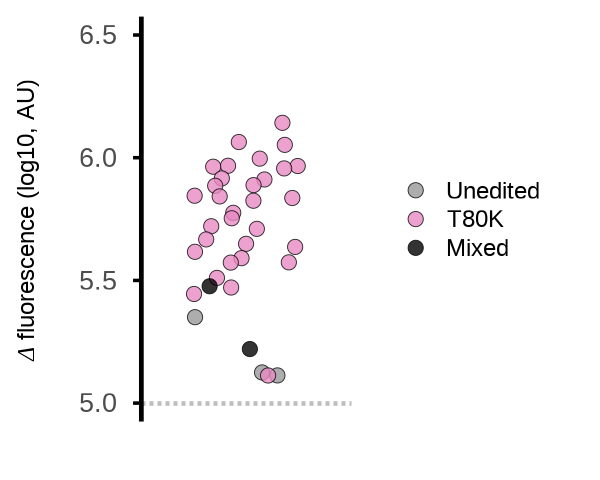

In [8]:
#Visualise the distribution of genotypes in the dot plots
options(repr.plot.width = 5, repr.plot.height = 4)

# Threshold
threshold_log10 <- 5

# Prepare plot dataframe
plot_df <- merged_res %>%
  filter(!is.na(signal) & signal > 0) %>%
  mutate(
    Value = signal,
    Genotype = factor(
      recode(genotype,
             "WT" = "Unedited",
             "T>K" = "T80K",
             "Not Sure" = "Mixed"),
      levels = c("Unedited", "T80K", "Mixed")
    ),
    AboveThreshold = Value > threshold_log10
  )

# Plot all samples as one column, color by genotype
ggplot(plot_df, aes(x = "Sample", y = Value, fill = Genotype)) +
  geom_jitter(
    color = "black",
    width = 0.3,
    alpha = 0.8,
    size = 3.8,
    shape = 21,
    stroke = 0.3
  ) +
  geom_hline(
    yintercept = threshold_log10,
    linetype = "dashed",
    color = "gray",
    size = 1
  ) +
  scale_fill_manual(
    values = c("Unedited" = "#999999", "T80K" = "#E78AC3", "Mixed" = "#000000")
  ) +
  guides(fill = guide_legend(title = NULL)) +
  scale_y_continuous(limits = c(5, 6.5), breaks = c(5, 5.5, 6, 6.5))+
  theme_minimal(base_size = 20) +
  ylab(expression(Delta * " fluorescence (log10, AU)")) +
  xlab("") +
  theme(
    axis.text.x = element_blank(),  # hide x-axis label since only one column
    axis.ticks.x = element_blank(),
    axis.text.y = element_text(size = 20, vjust = 0.5, hjust = 1, margin = margin(r = 10)),
    axis.ticks.y = element_line(size = 0.75),
    legend.position = "right",
    axis.title.y = element_text(size = 18, margin = margin(r = 15)),
    legend.text = element_text(size = 18),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    panel.border = element_blank(),
    axis.line.y = element_line(color = "black", size = 1)
  )
ggsave("data/POOL_T80K_genotype.pdf", plot = last_plot(), width = 5, height = 4, units = "in", device = pdf)

In [9]:
#WT positive cells

WT <- unname(unlist(df_delta[, paste0("POOL_WT_", 1)]))

# Log10 transform
WT <- log10(WT) #minus values will be NA

# Threshold
threshold_log10 <- 5

# Filter values above threshold, safely removing NAs
filtered <- WT[!is.na(WT) & WT > threshold_log10] 

# Create dataframe with sample names
res <- data.frame(
  sample = paste0("W", seq_along(filtered)),
  signal = filtered
)

head(res)

,sample,signal
,<chr>,<dbl>
1,W1,5.516577
2,W2,5.753502
3,W3,6.135685
4,W4,5.998328
5,W5,5.772190
6,W6,6.236560


In [10]:
#single cell genotyping result (output from "genotyping_single_cells_Fig3C.ipynb")
genotype <- read.csv("data/genotyping_single_cells_result_20bp.csv", header=TRUE)
rownames(genotype) <- genotype$X
genotype_long <- data.frame(
  sample = colnames(genotype),
  genotype = as.character(genotype["genotype", ])
)

# Merge with res by sample
merged_res <- merge(res, genotype_long, by = "sample")

merged_res <- merged_res[order(merged_res$signal, decreasing = TRUE), ]

head(merged_res)
table(merged_res$genotype)

,sample,signal,genotype
,<chr>,<dbl>,<chr>
24,W38,6.327396,WT
21,W34,6.270532,WT
13,W26,6.252159,WT
27,W44,6.249487,WT
31,W6,6.236560,WT
10,W22,6.161865,WT



Mixed  T80K    WT 
    1     1    32 

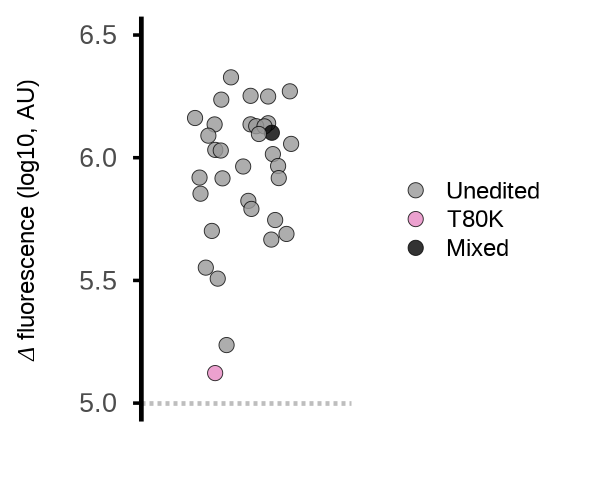

In [11]:
#Visualise the distribution of genotypes in the dot plots
options(repr.plot.width = 5, repr.plot.height = 4)

# Threshold
threshold_log10 <- 5

# Prepare plot dataframe
plot_df <- merged_res %>%
  filter(!is.na(signal) & signal > 0) %>%
  mutate(
    Value = signal,
    Genotype = factor(
      recode(genotype,
             "WT" = "Unedited",
             "T>K" = "T80K",
             "Not Sure" = "Mixed"),
      levels = c("Unedited", "T80K", "Mixed")
    ),
    AboveThreshold = Value > threshold_log10
  )

# Plot all samples as one column, color by genotype
ggplot(plot_df, aes(x = "Sample", y = Value, fill = Genotype)) +
  geom_jitter(
    color = "black",
    width = 0.3,
    alpha = 0.8,
    size = 3.8,
    shape = 21,
    stroke = 0.3
  ) +
  geom_hline(
    yintercept = threshold_log10,
    linetype = "dashed",
    color = "gray",
    size = 1
  ) +
  scale_fill_manual(
    values = c("Unedited" = "#999999", "T80K" = "#E78AC3", "Mixed" = "#000000")
  ) +
  guides(fill = guide_legend(title = NULL)) +
  scale_y_continuous(limits = c(5, 6.5), breaks = c(5, 5.5, 6, 6.5))+
  theme_minimal(base_size = 20) +
  ylab(expression(Delta * " fluorescence (log10, AU)")) +
  xlab("") +
  theme(
    axis.text.x = element_blank(),  # hide x-axis label since only one column
    axis.ticks.x = element_blank(),
    axis.text.y = element_text(size = 20, vjust = 0.5, hjust = 1, margin = margin(r = 10)),
    axis.ticks.y = element_line(size = 0.75),
    legend.position = "right",
    axis.title.y = element_text(size = 18, margin = margin(r = 15)),
    legend.text = element_text(size = 18),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    panel.border = element_blank(),
    axis.line.y = element_line(color = "black", size = 1)
  )
ggsave("data/POOL_WT_genotype.pdf", plot = last_plot(), width = 5, height = 4, units = "in", device = pdf)

In [12]:
sessionInfo()

R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS/LAPACK: /software/cellgen/team205/si9/envs/Seurat/lib/libopenblasp-r0.3.28.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=C.UTF-8    LC_NUMERIC=C        LC_TIME=C          
 [4] LC_COLLATE=C        LC_MONETARY=C       LC_MESSAGES=C      
 [7] LC_PAPER=C          LC_NAME=C           LC_ADDRESS=C       
[10] LC_TELEPHONE=C      LC_MEASUREMENT=C    LC_IDENTIFICATION=C

time zone: Europe/London
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] showtext_0.9-7  showtextdb_3.0  sysfonts_0.8.9  ggrepel_0.9.6  
 [5] lubridate_1.9.4 forcats_1.0.0   stringr_1.5.2   dplyr_1.1.4    
 [9] purrr_1.1.0     readr_2.1.5     tidyr_1.3.1     tibble_3.3.0   
[13] ggplot2_3.5.2   tidyverse_2.0.0

loaded via a namespace (and not attached):
  [1] RColorBrewer_1.1-3